In [4]:
import os
os.listdir('/kaggle/input/datasets')

['sovitrath']

In [7]:
import os

path = "/kaggle/input/datasets/sovitrath/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images"

os.listdir(path)[:10]

['gaussian_filtered_images']

In [8]:
import os

path = "/kaggle/input/datasets/sovitrath/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images"

os.listdir(path)[:10]

['Mild', 'Proliferate_DR', 'Moderate', 'export.pkl', 'No_DR', 'Severe']

In [9]:
import os

mild_path = "/kaggle/input/datasets/sovitrath/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images/Mild"

os.listdir(mild_path)[:10]

['f481f76a6b75.png',
 'abdb365cacbc.png',
 '33ffddea8c6e.png',
 '059bc89df7f4.png',
 '278aa860dffd.png',
 'd66b6f333dc7.png',
 'a8c950a99107.png',
 'cab3dfa7962d.png',
 '63363410389a.png',
 '4da2961e62fe.png']

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

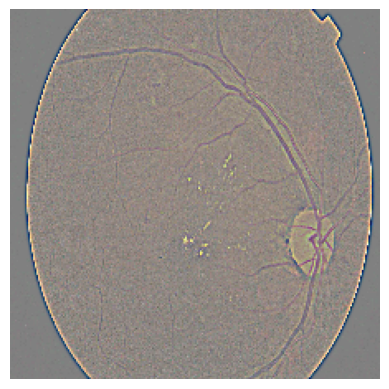

In [10]:
from PIL import Image
import matplotlib.pyplot as plt
import os

mild_path = "/kaggle/input/datasets/sovitrath/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images/Mild"

img_name = os.listdir(mild_path)[0]   # first image
img_path = os.path.join(mild_path, img_name)

img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")

In [12]:
import tensorflow as tf

dataset_path = "/kaggle/input/datasets/sovitrath/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images"

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(224,224),
    batch_size=32
)

class_names = train_data.class_names
print(class_names)

Found 3662 files belonging to 5 classes.
['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']


In [14]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))

In [15]:
from tensorflow.keras import layers, models

model = models.Sequential([
    
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(5, activation='softmax')   # 5 DR classes
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    train_data,
    epochs=5
)

Epoch 1/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.4281 - loss: 1.3630
Epoch 2/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.4804 - loss: 1.3160
Epoch 3/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.4779 - loss: 1.3186
Epoch 4/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.4789 - loss: 1.3398
Epoch 5/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.4746 - loss: 1.3190


In [19]:
import os
print(os.listdir(dataset_path)[:10])

['Mild', 'Proliferate_DR', 'Moderate', 'export.pkl', 'No_DR', 'Severe']


In [22]:
import tensorflow as tf

dataset_path = "/kaggle/input/datasets/sovitrath/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images"

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

Found 3662 files belonging to 5 classes.
Using 2930 files for training.


In [23]:
val_data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

Found 3662 files belonging to 5 classes.
Using 732 files for validation.


In [24]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.4288 - loss: 44.9602 - val_accuracy: 0.5041 - val_loss: 1.3210
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.4835 - loss: 1.3177 - val_accuracy: 0.5041 - val_loss: 1.2834
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.4883 - loss: 1.2940 - val_accuracy: 0.5041 - val_loss: 1.2820
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.4841 - loss: 1.3081 - val_accuracy: 0.5041 - val_loss: 1.2817
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.4909 - loss: 1.2926 - val_accuracy: 0.5041 - val_loss: 1.2816


In [25]:
train_data.class_names

['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']

In [27]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
val_data = val_data.map(lambda x, y: (normalization_layer(x), y))

In [29]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(5,activation='softmax')
])

In [30]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

In [34]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.4629 - loss: 1.3567 - val_accuracy: 0.5041 - val_loss: 1.2994
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.4908 - loss: 1.3091 - val_accuracy: 0.5041 - val_loss: 1.2835
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.4899 - loss: 1.3133 - val_accuracy: 0.5041 - val_loss: 1.2874
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.4836 - loss: 1.3170 - val_accuracy: 0.5041 - val_loss: 1.2921
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.4914 - loss: 1.2963 - val_accuracy: 0.5041 - val_loss: 1.2744
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.5094 - loss: 1.2317 - val_accuracy: 0.6803 - val_loss: 0.8994
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.6777 - loss: 0.8899 - val_accuracy: 0.6981 - val_loss: 0.8100
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.6895 - loss: 0.8621 - val_accuracy: 0.7022 - v

In [36]:
model.save("/kaggle/working/dr_model_72.h5")

In [37]:
import os
os.listdir("/kaggle/working")

['.virtual_documents', 'dr_model_72.h5']

In [39]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [41]:
model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(5,activation='softmax')
])

In [42]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [43]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25
)

Epoch 1/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.4665 - loss: 1.4439 - val_accuracy: 0.5041 - val_loss: 1.2850
Epoch 2/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.4961 - loss: 1.3092 - val_accuracy: 0.5041 - val_loss: 1.2834
Epoch 3/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.4885 - loss: 1.3056 - val_accuracy: 0.5041 - val_loss: 1.2846
Epoch 4/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.4896 - loss: 1.3114 - val_accuracy: 0.5041 - val_loss: 1.2818
Epoch 5/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.4889 - loss: 1.3108 - val_accuracy: 0.5041 - val_loss: 1.2816
Epoch 6/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.4899 - loss: 1.3045 - val_accuracy: 0.5041 - val_loss: 1.2814
Epoch 7/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.4852 - loss: 1.3161 - val_accuracy: 0.5041 - val_loss: 1.2814
Epoch 8/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.4882 - loss: 1.3217 - val_accuracy: 0.5041 - v